# Taller 3: Exploratory Data Analysis (EDA) y Data Wrangling

## Introducción

Instacart es una plataforma de entrega de comestibles donde los clientes pueden hacer un pedido y recibirlo, de manera similar a como funcionan Uber Eats y Door Dash.
El conjunto de datos que se te ha proporcionado ha sido modificado del original. Hemos reducido el tamaño del conjunto para que tus cálculos se ejecuten más rápido y hemos introducido deliberadamente valores ausentes (missing values) y duplicados. Sin embargo, hemos conservado las distribuciones poblacionales de los datos originales.

**Tu misión profesional:** Como Científico de Datos, aplicarás metodológicamente las 4 dimensiones de la calidad de los datos para auditar tu dataset. Luego, realizarás un análisis exploratorio empleando medidas de tendencia central, variabilidad, diagramas de dispersión, y responderás preguntas de negocio tras construir una tabla desnormalizada (One Big Table - OBT).

> **Aviso Importante:** Para cada paso, escribe introducciones donde expongas qué harás, bloques intermedios justificando el porqué de tus decisiones y tu limpieza estadística, y cierra siempre con una conclusión de lo hallado.

## Diccionario de Datos

Hay cinco tablas en el conjunto de datos que deberás usar en conjunto:

- `instacart_orders.csv`: cada fila es un pedido en la app de Instacart
    - `'order_id'`: ID que identifica de manera única cada pedido
    - `'user_id'`: ID que identifica de manera única a cada cliente
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 es domingo)
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido
    - `'days_since_prior_order'`: número de días desde que este cliente hizo su último pedido
- `products.csv`: cada fila corresponde a un producto
    - `'product_id'`: ID único del producto
    - `'product_name'`: nombre del producto
    - `'aisle_id'`: ID único de la categoría del pasillo
    - `'department_id'`: ID único de la categoría del departamento
- `order_products.csv`: cada fila corresponde a un artículo en un pedido
    - `'order_id'`: ID único del pedido
    - `'product_id'`: ID único del producto
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo al carrito
    - `'reordered'`: 0 si el cliente no había pedido este producto antes, 1 si ya lo había hecho
- `aisles.csv`
    - `'aisle_id'`: ID único del pasillo
    - `'aisle'`: nombre del pasillo
- `departments.csv`
    - `'department_id'`: ID único del departamento
    - `'department'`: nombre del departamento

# Paso 1: Exploración Inicial

Lee los archivos ubicados en el directorio `/datos/` (`instacart_orders.csv`, `products.csv`, `aisles.csv`, `departments.csv` y `order_products.csv`) fijándote que algunos están separados por `;` u otros delimitadores. 

Tras leerlos, ejecuta funciones de inspección básica (`head()`, `info()`) y comprueba una muestra aleatoria (Muestreo Aleatorio Simple usando `sample()`) de cada tabla para evitar el *sesgo de posición*. Verifica si los tipos computacionales coinciden con su rol estadístico esperado.

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from pathlib import Path

In [47]:
ruta = Path("./datos")   

instacart_orders = pd.read_csv(ruta / "instacart_orders.csv", sep=";")
products = pd.read_csv(ruta / "products.csv", sep=";")
aisles = pd.read_csv(ruta / "aisles.csv", sep=";")
departments = pd.read_csv(ruta / "departments.csv", sep=";")
order_products = pd.read_csv(ruta / "order_products.csv", sep=";")

In [48]:
tablas = {
    "instacart_orders": instacart_orders,
    "products": products,
    "aisles": aisles,
    "departments": departments,
    "order_products": order_products
}

for nombre, df in tablas.items():
    print("\n" + "="*80)
    print(f"TABLA: {nombre}")
    print("="*80)

    print("\nHEAD()")
    display(df.head())

    print("\nINFO()")
    df.info()

    print("\nSAMPLE()")
    display(df.sample(5, random_state=42))


TABLA: instacart_orders

HEAD()


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0



INFO()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB

SAMPLE()


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
478011,187515,84759,1,2,15,NaN
176737,14154,184924,41,2,15,3.0
402189,1978043,151955,21,1,23,7.0
111658,2907266,43250,11,1,8,1.0
59935,3245658,115414,5,2,10,7.0



TABLA: products

HEAD()


...

,department_id,department
0,1,frozen
17,18,babies
15,16,dairy eggs
1,2,other
8,9,dry goods pasta



TABLA: order_products

HEAD()


,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1



INFO()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB

SAMPLE()


,order_id,product_id,add_to_cart_order,reordered
1274557,2182877,36412,2.0,0
136271,1692632,49383,19.0,0
2327440,1054700,11520,9.0,1
1228514,2495519,9973,9.0,0
1462440,2330427,27845,3.0,1


### Escribe tus hallazgos iniciales aquí:
(Escribe textualmente qué dimensiones, tipos de datos ves incoherentes y qué opinas estadísticamente de la primera radiografía de los datos).

Hay cinco tablas con tamaños muy distintos: order_products es la más grande y transaccional, mientras aisles y departments son catálogos pequeños. Esto es coherente con una estructura relacional.

Los tipos de datos muestran algunas incoherencias estadísticas. Aunque varias columnas están como int64, muchas no son variables numéricas reales sino identificadores, como order_id, user_id, product_id, aisle_id y department_id. Además, order_dow y order_hour_of_day son variables discretas, no continuas; reordered es binaria; y days_since_prior_order y add_to_cart_order aparecen como float64, aunque conceptualmente deberían ser enteras, probablemente por la presencia de valores faltantes

# Paso 2: Auditoría de Calidad de Datos (4 Dimensiones)

Basado en la teoría vista, somete a tus 5 tablas al escrutinio en las cuatro dimensiones.

## 2.1 Precisión: Identificación y limpieza de duplicados explícitos e implícitos
Encuentra y elimina duplicados explícitos en la tabla de `orders`. Nota si se agrupan por algún motivo (¿Son de un día y hora en particular?). Asimismo, busca duplicados por ID de producto (tricky duplicates) o nombres duplicados con problemas de mayúsculas y minúsculas.

In [49]:
#  Encontrar duplicados exactos
n_dup_orders = instacart_orders.duplicated().sum()
print("Duplicados explícitos en instacart_orders:", n_dup_orders)

dup_orders = instacart_orders[instacart_orders.duplicated(keep=False)].sort_values(
    ["order_id", "user_id", "order_number", "order_dow", "order_hour_of_day"]
)

dup_orders

Duplicados explícitos en instacart_orders: 15


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
354993,391768,57671,19,3,2,10.0
371905,391768,57671,19,3,2,10.0
119251,408114,68324,4,3,2,18.0
321100,408114,68324,4,3,2,18.0
250626,467134,63189,21,3,2,2.0
394347,467134,63189,21,3,2,2.0
99462,794638,50898,24,3,2,2.0
145574,794638,50898,24,3,2,2.0
242618,1021560,53767,3,3,2,9.0
311713,1021560,53767,3,3,2,9.0


In [50]:
dup_orders.groupby(["order_dow", "order_hour_of_day"]).size().reset_index(name="filas_duplicadas")

,order_dow,order_hour_of_day,filas_duplicadas
0,3,2,30


In [51]:
# Eliminar duplicados exactos
# Criterio: conservar la primera aparición de cada fila idéntica
instacart_orders_clean = instacart_orders.drop_duplicates().copy()

print("Shape original:", instacart_orders.shape)
print("Shape sin duplicados:", instacart_orders_clean.shape)
print("Duplicados restantes:", instacart_orders_clean.duplicated().sum())

Shape original: (478967, 6)
Shape sin duplicados: (478952, 6)
Duplicados restantes: 0


In [52]:
# Buscar duplicados por ID de producto
dup_product_id = products[products.duplicated(subset=["product_id"], keep=False)].sort_values("product_id")

print("Filas duplicadas por product_id:", dup_product_id.shape[0])
dup_product_id

Filas duplicadas por product_id: 0


,product_id,product_name,aisle_id,department_id


In [53]:
# Normalizar nombres para detectar tricky duplicates textuales
products_aux = products.copy()
products_aux["product_name_norm"] = products_aux["product_name"].str.strip().str.lower()

dup_names = products_aux[
    products_aux["product_name"].notna() &
    products_aux.duplicated(subset=["product_name_norm"], keep=False)
].sort_values(["product_name_norm", "product_id"])

print("Filas con nombres duplicados tras normalizar:", dup_names.shape[0])
print("Cantidad de nombres normalizados duplicados:", dup_names["product_name_norm"].nunique())

dup_names[["product_id", "product_name", "product_name_norm", "aisle_id", "department_id"]].head(30)

Filas con nombres duplicados tras normalizar: 207
Cantidad de nombres normalizados duplicados: 103


,product_id,product_name,product_name_norm,aisle_id,department_id
23339,23340,18-in-1 Hemp Peppermint Pure-Castile Soap,18-in-1 hemp peppermint pure-castile soap,25,11
31844,31845,18-In-1 Hemp Peppermint Pure-Castile Soap,18-in-1 hemp peppermint pure-castile soap,25,11
13152,13153,Aged Balsamic Vinegar of Modena,aged balsamic vinegar of modena,19,13
19941,19942,Aged Balsamic Vinegar Of Modena,aged balsamic vinegar of modena,19,13
22582,22583,Albacore Solid White Tuna In Water,albacore solid white tuna in water,95,15
24830,24831,Albacore Solid White Tuna in Water,albacore solid white tuna in water,95,15
515,516,American Cheese Slices,american cheese slices,21,16
9037,9038,American Cheese slices,american cheese slices,21,16
12325,12326,Anchovy Fillets in Olive Oil,anchovy fillets in olive oil,95,15
49530,49531,Anchovy Fillets In Olive Oil,anchovy fillets in olive oil,95,15


In [54]:
# Duplicados textuales "seguros":
# mismo nombre normalizado + mismo aisle_id + mismo department_id
dup_names_same_cat = products_aux[
    products_aux["product_name"].notna()
].groupby(["product_name_norm", "aisle_id", "department_id"]).filter(lambda g: len(g) > 1)

dup_names_same_cat = dup_names_same_cat.sort_values(
    ["product_name_norm", "aisle_id", "department_id", "product_id"]
)

print("Filas duplicadas con mismo nombre normalizado y misma categoría:", dup_names_same_cat.shape[0])
dup_names_same_cat[["product_id", "product_name", "product_name_norm", "aisle_id", "department_id"]].head(30)

Filas duplicadas con mismo nombre normalizado y misma categoría: 174


,product_id,product_name,product_name_norm,aisle_id,department_id
23339,23340,18-in-1 Hemp Peppermint Pure-Castile Soap,18-in-1 hemp peppermint pure-castile soap,25,11
31844,31845,18-In-1 Hemp Peppermint Pure-Castile Soap,18-in-1 hemp peppermint pure-castile soap,25,11
13152,13153,Aged Balsamic Vinegar of Modena,aged balsamic vinegar of modena,19,13
19941,19942,Aged Balsamic Vinegar Of Modena,aged balsamic vinegar of modena,19,13
22582,22583,Albacore Solid White Tuna In Water,albacore solid white tuna in water,95,15
24830,24831,Albacore Solid White Tuna in Water,albacore solid white tuna in water,95,15
515,516,American Cheese Slices,american cheese slices,21,16
9037,9038,American Cheese slices,american cheese slices,21,16
12325,12326,Anchovy Fillets in Olive Oil,anchovy fillets in olive oil,95,15
49530,49531,Anchovy Fillets In Olive Oil,anchovy fillets in olive oil,95,15


In [55]:
# Duplicados ambiguos:
# mismo nombre normalizado, pero en distinta categoría
resumen_norm = products_aux[products_aux["product_name"].notna()].groupby("product_name_norm").agg(
    n_filas=("product_id", "size"),
    n_aisles=("aisle_id", "nunique"),
    n_departments=("department_id", "nunique")
).reset_index()

ambiguous_names = resumen_norm[
    (resumen_norm["n_filas"] > 1) &
    ((resumen_norm["n_aisles"] > 1) | (resumen_norm["n_departments"] > 1))
]["product_name_norm"]

dup_names_ambiguous = products_aux[products_aux["product_name_norm"].isin(ambiguous_names)].sort_values(
    ["product_name_norm", "product_id"]
)

print("Filas ambiguas (mismo nombre normalizado pero distinta categoría):", dup_names_ambiguous.shape[0])
dup_names_ambiguous[["product_id", "product_name", "product_name_norm", "aisle_id", "department_id"]].head(30)

Filas ambiguas (mismo nombre normalizado pero distinta categoría): 35


,product_id,product_name,product_name_norm,aisle_id,department_id
11163,11164,Blanc De Noirs,blanc de noirs,62,5
44078,44079,Blanc de Noirs,blanc de noirs,134,5
10747,10748,Chicken with Rice Soup,chicken with rice soup,69,15
31292,31293,Chicken With Rice Soup,chicken with rice soup,13,20
18312,18313,Chopped Garlic in Water,chopped garlic in water,123,4
29911,29912,Chopped Garlic In Water,chopped garlic in water,81,15
21749,21750,Edamame Soybeans In Pods,edamame soybeans in pods,83,4
30674,30675,Edamame Soybeans in Pods,edamame soybeans in pods,116,1
2037,2038,Green Tea with Ginseng and Honey,green tea with ginseng and honey,94,7
5455,5456,Green Tea With Ginseng and Honey,green tea with ginseng and honey,96,20


In [56]:
# Eliminar solo los duplicados textuales seguros
# Criterio: dentro de cada grupo (nombre normalizado + aisle_id + department_id)
# conservar el menor product_id y eliminar los demás.
products_clean = products_aux.sort_values("product_id").drop_duplicates(
    subset=["product_name_norm", "aisle_id", "department_id"],
    keep="first"
).copy()

print("Shape original products:", products.shape)
print("Shape products_clean:", products_clean.shape)
print("Filas eliminadas:", products.shape[0] - products_clean.shape[0])

Shape original products: (49694, 4)
Shape products_clean: (48350, 5)
Filas eliminadas: 1344


In [57]:
# Verificación: ya no deben quedar duplicados textuales "seguros"
verif = products_clean.groupby(["product_name_norm", "aisle_id", "department_id"]).size().reset_index(name="n")
verif[verif["n"] > 1].head()

,product_name_norm,aisle_id,department_id,n


In [58]:
# tablas limpias 
instacart_orders = instacart_orders_clean
products = products_clean.drop(columns=["product_name_norm"])

### Conclusiones sobre la Precisión:
Explica por qué eliminaste (o consolidaste) la información y qué nos enseña sobre la ingesta del sistema.

Se eliminaron los duplicados explícitos de instacart_orders porque eran registros totalmente idénticos y no agregaban información real, solo duplicaban artificialmente el número de órdenes. En products no hubo duplicados por product_id, pero sí se consolidaron algunos duplicados implícitos de product_name cuando, además de coincidir el nombre normalizado, también coincidían aisle_id y department_id; en esos casos se conservó el menor product_id y se eliminaron los demás. Los casos ambiguos no se tocaron (no había evidencia suficiente para asegurar que fueran el mismo producto). Esto muestra que la ingesta del sistema tiene fallas de calidad: hubo una duplicación puntual en órdenes, probablemente por reprocesamiento o carga repetida, y también falta de estandarización en los nombres de productos.

## 2.2 Completitud: Tratamiento de Valores Ausentes
Navega por las tablas en busca de NaNs. Es crítico que analices si el patrón de valores ausentes se trata de MCAR (Missing Completely at Random), MAR o MNAR.

1. Revisa nombres de productos vacíos.
2. Revisa NaNs en `days_since_prior_order`. (¿Son clientes haciendo su primera orden?)
3. Revisa `add_to_cart_order` en `order_products`. (¿Qué pasa después de 64 artículos?)

Decide si debes imputar por tendencia central, usar ML, imputar un valor indicador ficticio (e.g. -1 o 'Desconocido') o eliminar las filas. ¡Aplica tus soluciones!

In [59]:
# products ya fue modificada, por eso se recarga el original para auditar su completitud real
products_qc = pd.read_csv(ruta / "products.csv", sep=";")

orders_qc = instacart_orders.copy()          # idealmente ya sin duplicados explícitos
order_products_qc = order_products.copy()
aisles_qc = aisles.copy()
departments_qc = departments.copy()

tablas_qc = {
    "instacart_orders": orders_qc,
    "products": products_qc,
    "aisles": aisles_qc,
    "departments": departments_qc,
    "order_products": order_products_qc
}

for nombre, df in tablas_qc.items():
    faltantes = df.isna().sum()
    faltantes = faltantes[faltantes > 0]
    print(f"\n{nombre}")
    display(
        pd.DataFrame({
            "faltantes": faltantes,
            "porcentaje_%": (faltantes / len(df) * 100).round(3)
        })
    )


instacart_orders


,faltantes,porcentaje_%
days_since_prior_order,28817,6.017



products


,faltantes,porcentaje_%
product_name,1258,2.531



aisles


,faltantes,porcentaje_%



departments


,faltantes,porcentaje_%



order_products


,faltantes,porcentaje_%
add_to_cart_order,836,0.018


In [60]:
#Revisar product_name vacío
products_nan = products_qc[products_qc["product_name"].isna()].copy()

print("Filas con product_name vacío:", products_nan.shape[0])
display(products_nan.head())

Filas con product_name vacío: 1258


,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21


In [61]:
products_nan_merge = (
    products_nan
    .merge(aisles_qc, on="aisle_id", how="left")
    .merge(departments_qc, on="department_id", how="left")
)

print("Aisles involucrados:")
display(products_nan_merge["aisle"].value_counts(dropna=False))

print("Departments involucrados:")
display(products_nan_merge["department"].value_counts(dropna=False))

Aisles involucrados:


aisle
missing    1258
Name: count, dtype: int64

Departments involucrados:


department
missing    1258
Name: count, dtype: int64

In [62]:
#todos los product_name vacíos están en:

#aisle_id = 100 → aisle = "missing"
#department_id = 21 → department = "missing"
#Esto indica que no es MCAR. No faltan al azar. Es una ausencia estructural y más cercana a MAR

In [63]:
#No conviene usar media, mediana ni ML. Tampoco conviene eliminar filas porque perderías 1258 productos catalogados como “missing”.
#La solución más coherente es imputar un valor indicador. En este caso, "Unknown" o "Missing" podrían ser opciones razonables para indicar que el nombre del producto no está disponible.
products_qc["product_name"] = products_qc["product_name"].fillna("Unknown")

In [64]:
#Revisar days_since_prior_order
orders_nan = orders_qc[orders_qc["days_since_prior_order"].isna()].copy()

print("NaNs en days_since_prior_order:", orders_nan.shape[0])
print("\nDistribución de order_number entre los NaNs:")
display(orders_nan["order_number"].value_counts().sort_index())

NaNs en days_since_prior_order: 28817

Distribución de order_number entre los NaNs:


order_number
1    28817
Name: count, dtype: int64

In [65]:
print("¿Todos los NaNs son order_number == 1?:",
      orders_qc.loc[orders_qc["days_since_prior_order"].isna(), "order_number"].eq(1).all())

print("¿Existe algún order_number > 1 con NaN?:",
      orders_qc.loc[orders_qc["order_number"] > 1, "days_since_prior_order"].isna().any())

¿Todos los NaNs son order_number == 1?: True
¿Existe algún order_number > 1 con NaN?: False


In [66]:
#No es MCAR. Es una ausencia estructural: en la primera orden no existe una orden previa contra la cual medir días. Esto también se puede considerar MAR por diseño, porque la ausencia depende de una variable observada (order_number)
#Solución aplicada:
#No conviene eliminar filas, porque se perderia todas las primeras órdenes.
#Tampoco conviene imputar con media o mediana, porque sería semánticamente incorrecto.
#La mejor práctica es:imputar un valor ficticio que no se confunda con un valor real. En este caso, -1 podría ser una opción razonable para indicar que no hay una orden previa.

orders_qc["is_first_order"] = (orders_qc["order_number"] == 1).astype(int)
orders_qc["days_since_prior_order"] = orders_qc["days_since_prior_order"].fillna(-1)

In [67]:
#Revisar add_to_cart_order en order_products

op_nan = order_products_qc[order_products_qc["add_to_cart_order"].isna()].copy()

print("NaNs en add_to_cart_order:", op_nan.shape[0])
print("Órdenes afectadas:", op_nan["order_id"].nunique())
display(op_nan.head())

NaNs en add_to_cart_order: 836
Órdenes afectadas: 70


,order_id,product_id,add_to_cart_order,reordered
737,2449164,5068,NaN,0
9926,1968313,43867,NaN,0
14394,2926893,11688,NaN,0
16418,1717990,4142,NaN,0
30114,1959075,42828,NaN,1


In [68]:
order_sizes = order_products_qc.groupby("order_id").size().rename("n_items")
order_missing = order_products_qc.groupby("order_id")["add_to_cart_order"].apply(lambda s: s.isna().sum()).rename("n_missing")
order_max = order_products_qc.groupby("order_id")["add_to_cart_order"].max().rename("max_add_to_cart_order")

resumen_orders = pd.concat([order_sizes, order_missing, order_max], axis=1).reset_index()
resumen_nan_orders = resumen_orders[resumen_orders["n_missing"] > 0].copy()

display(resumen_nan_orders.head(10))

,order_id,n_items,n_missing,max_add_to_cart_order
1274,9310,65,1,64.0
8201,61355,127,63,64.0
13574,102236,95,31,64.0
17108,129627,69,5,64.0
21882,165801,70,6,64.0
22701,171934,104,40,64.0
23795,180546,66,2,64.0
34723,264710,91,27,64.0
38394,293169,77,13,64.0
50749,388234,70,6,64.0


In [69]:
print("¿Todas las órdenes con NaN tienen más de 64 artículos?:",
      (resumen_nan_orders["n_items"] > 64).all())

print("¿El máximo add_to_cart_order observado en esas órdenes es siempre 64?:",
      (resumen_nan_orders["max_add_to_cart_order"] == 64).all())

print("¿Se cumple n_missing = n_items - 64 en todas esas órdenes?:",
      (resumen_nan_orders["n_missing"] == resumen_nan_orders["n_items"] - 64).all())

¿Todas las órdenes con NaN tienen más de 64 artículos?: True
¿El máximo add_to_cart_order observado en esas órdenes es siempre 64?: True
¿Se cumple n_missing = n_items - 64 en todas esas órdenes?: True


In [70]:
#Esto indica que no es MCAR. Tampoco conviene tratarlo como aleatorio. Aquí hay una truncación del sistema: después del artículo 64, el orden exacto dejó de registrarse. Eso es una ausencia sistemática y, en la práctica, se comporta como MNAR/censura por sistema, porque el valor faltante justamente corresponde a posiciones mayores que 64

In [71]:
#Solución aplicada

#No conviene eliminar filas porque perderías productos reales.
#No conviene media/mediana ni ML, porque el patrón ya está explicado por una limitación del sistema.

#La solución es:
#crear una bandera de overflow
#imputar 65 como categoría “65 o más”
order_products_qc["add_to_cart_overflow_64"] = order_products_qc["add_to_cart_order"].isna().astype(int)
order_products_qc["add_to_cart_order"] = order_products_qc["add_to_cart_order"].fillna(65)
order_products_qc["add_to_cart_order"] = order_products_qc["add_to_cart_order"].astype(int)

In [72]:
#Verificación final
for nombre, df in {
    "instacart_orders": orders_qc,
    "products": products_qc,
    "order_products": order_products_qc
}.items():
    print(f"\n{nombre}")
    print(df.isna().sum()[df.isna().sum() > 0])


instacart_orders
Series([], dtype: int64)

products
Series([], dtype: int64)

order_products
Series([], dtype: int64)


### Conclusiones sobre la Completitud:
Argumenta qué mecanismo de ausencia (Rubin) encontraste en cada escenario y por qué tus estrategias de imputación no generaron sesgos severos.

En products, la ausencia en product_name corresponde a un patrón MAR estructural, porque los NaN se concentran en categorías observables (aisle = missing y department = missing) y no aparecen al azar. Por eso se imputó "Unknown", una etiqueta que no inventa información y evita sesgos severos.

En instacart_orders, los NaN de days_since_prior_order también responden a un patrón MAR por diseño, ya que solo aparecen cuando order_number = 1; es decir, no existe una orden previa. Se creó is_first_order y se imputó -1, lo que evita distorsionar la variable con promedios o medianas artificiales.

En order_products, los NaN de add_to_cart_order siguen un patrón sistemático cercano a MNAR, porque aparecen solo en órdenes con más de 64 artículos y corresponden a posiciones posteriores a ese límite. Se imputó 65 y se creó una bandera add_to_cart_overflow_64, lo que conserva la información sin inventar posiciones exactas.

En resumen, las estrategias aplicadas no generan sesgos severos porque no reemplazan los faltantes con valores arbitrarios, sino que respetan el significado real de cada ausencia y preservan la lógica del proceso de captura de datos.

## 2.3 Sensibilidad: Tratamiento de Outliers (Valores Atípicos)
Centra tu atención en la tabla de órdenes, específicamente en `days_since_prior_order` o conteos agrupados. Usando gráficos estadísticos (Boxplots) y computando el Rango Intercuartílico (IQR / Regla de Tukey) o Z-Scores, encuentra y reporta valores atípicos. ¿Existen usuarios que compran muy fuera del rango promedio de frecuencia?

In [73]:
# Tabla de órdenes ya sin duplicados explícitos
orders_sens = instacart_orders.copy()

# En 2.2 se imputo -1 para primeras órdenes, aquí se excluye
days_valid = orders_sens.loc[
    orders_sens["days_since_prior_order"].notna() &
    (orders_sens["days_since_prior_order"] >= 0),
    "days_since_prior_order"
].copy()

print("Cantidad de valores válidos en days_since_prior_order:", days_valid.shape[0])

Cantidad de valores válidos en days_since_prior_order: 450135


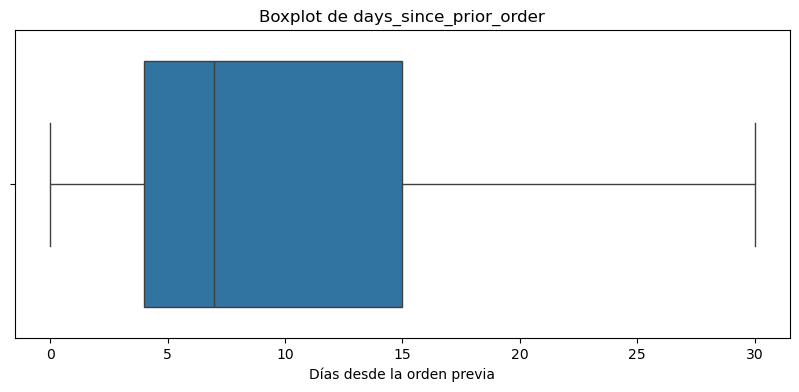

In [74]:
plt.figure(figsize=(10,4))
sns.boxplot(x=days_valid)
plt.title("Boxplot de days_since_prior_order")
plt.xlabel("Días desde la orden previa")
plt.show()

In [75]:
# IQR y Z-score para days_since_prior_order
q1 = days_valid.quantile(0.25)
q3 = days_valid.quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers_iqr_days = days_valid[(days_valid < lim_inf) | (days_valid > lim_sup)]

media_days = days_valid.mean()
std_days = days_valid.std(ddof=0)

z_days = (days_valid - media_days) / std_days
outliers_z_days = days_valid[z_days.abs() > 3]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Límite inferior:", lim_inf)
print("Límite superior:", lim_sup)
print("Outliers por IQR:", outliers_iqr_days.shape[0])
print("Outliers por Z-score:", outliers_z_days.shape[0])

Q1: 4.0
Q3: 15.0
IQR: 11.0
Límite inferior: -12.5
Límite superior: 31.5
Outliers por IQR: 0
Outliers por Z-score: 0


#No aparecen valores atípicos en days_since_prior_order. Esto tiene sentido porque la variable está acotada entre 0 y 30 días, así que no hay extremos fuera del rango esperado.

In [76]:

#Conteos agrupados por usuario: número de órdenes por usuario
user_order_counts = (
    orders_sens.groupby("user_id")
    .size()
    .reset_index(name="n_orders")
)

display(user_order_counts.head())
print(user_order_counts["n_orders"].describe())

,user_id,n_orders
0,2,2
1,4,2
2,5,1
3,6,2
4,7,2


count    157437.000000
mean          3.042182
std           2.746842
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          28.000000
Name: n_orders, dtype: float64


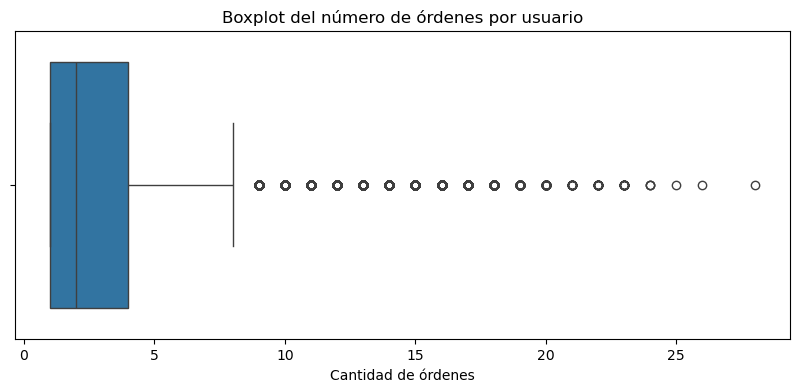

In [77]:
# Boxplot de órdenes por usuario
plt.figure(figsize=(10,4))
sns.boxplot(x=user_order_counts["n_orders"])
plt.title("Boxplot del número de órdenes por usuario")
plt.xlabel("Cantidad de órdenes")
plt.show()

In [78]:
#IQR y Z-score para n_orders por usuario
q1_u = user_order_counts["n_orders"].quantile(0.25)
q3_u = user_order_counts["n_orders"].quantile(0.75)
iqr_u = q3_u - q1_u

lim_inf_u = q1_u - 1.5 * iqr_u
lim_sup_u = q3_u + 1.5 * iqr_u

outliers_iqr_users = user_order_counts[
    (user_order_counts["n_orders"] < lim_inf_u) |
    (user_order_counts["n_orders"] > lim_sup_u)
].copy()

media_u = user_order_counts["n_orders"].mean()
std_u = user_order_counts["n_orders"].std(ddof=0)

user_order_counts["z_n_orders"] = (user_order_counts["n_orders"] - media_u) / std_u
outliers_z_users = user_order_counts[user_order_counts["z_n_orders"].abs() > 3].copy()

print("Q1:", q1_u)
print("Q3:", q3_u)
print("IQR:", iqr_u)
print("Límite inferior:", lim_inf_u)
print("Límite superior:", lim_sup_u)
print("Outliers por IQR:", outliers_iqr_users.shape[0])
print("Outliers por Z-score:", outliers_z_users.shape[0])

Q1: 1.0
Q3: 4.0
IQR: 3.0
Límite inferior: -3.5
Límite superior: 8.5
Outliers por IQR: 8479
Outliers por Z-score: 3374


In [79]:
print("Top usuarios con más órdenes:")
display(user_order_counts.sort_values("n_orders", ascending=False).head(10))

Top usuarios con más órdenes:


,user_id,n_orders,z_n_orders
114085,149605,28,9.086033
147428,193164,26,8.357922
59737,78375,25,7.993866
112979,148162,24,7.629811
50752,66664,24,7.629811
102607,134511,24,7.629811
21562,28284,23,7.265755
135009,176951,23,7.265755
8605,11236,23,7.265755
81602,106869,23,7.265755


In [80]:
print("Usuarios con más de 8 órdenes (criterio IQR > 8.5):",
      (user_order_counts["n_orders"] > 8.5).sum())

print("Usuarios con 12 o más órdenes (criterio Z-score > 3):",
      (user_order_counts["n_orders"] >= 12).sum())

Usuarios con más de 8 órdenes (criterio IQR > 8.5): 8479
Usuarios con 12 o más órdenes (criterio Z-score > 3): 3374


### Conclusiones sobre la Sensibilidad:
Decide y justifica la estrategia que usaste para estos casos (eliminar, mantener como outlier real o winsorizar).

Se decidió mantener los outliers reales y no eliminarlos ni winsorizarlos. En days_since_prior_order no se detectaron valores atípicos, por lo que no fue necesario aplicar ningún tratamiento. En los conteos de órdenes por usuario sí aparecieron valores extremos, pero estos no parecen errores de captura sino comportamientos reales de clientes muy frecuentes. Eliminarlos o winsorizarlos habría distorsionado la variabilidad natural del consumo y reducido información valiosa sobre usuarios intensivos. Por eso, la estrategia más adecuada fue conservarlos e interpretarlos como outliers reales.

# Paso 3: Data Wrangling & Construcción de One Big Table (OBT)

Para poder responder preguntas de negocio de manera eficiente y aplicando correlaciones y cruces, un científico de datos típicamente convierte o "aplana" las tablas normalizadas operacionales en **One Big Table (OBT)**. La OBT agrupa (hace merges) de las distintas dimensiones transaccionales alrededor del concepto central (en este caso el *Articulo pedido por Orden*), lo que nos da una vista panorámica (desnormalización estructural) para el análisis.

**Tu tarea:** Une las cinco tablas previamente purgadas formando un solo DataFrame analítico. Te recomendamos ir uniendo ordenes y el detalle, luego producto, pasillo y finalmente departamento.

In [81]:
# Órdenes limpias
orders_obt = instacart_orders.copy()

# Detalle de productos por orden
order_products_obt = order_products.copy()

# Productos limpios
products_obt = products.drop(columns=["product_name_norm"], errors="ignore").copy()

# Catálogos
aisles_obt = aisles.copy()
departments_obt = departments.copy()

In [82]:
#Unir órdenes + detalle
obt = order_products_obt.merge(
    orders_obt,
    on="order_id",
    how="left",
    validate="many_to_one"
)

print("Shape después de unir order_products + orders:", obt.shape)
display(obt.head())

Shape después de unir order_products + orders: (4545007, 9)


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2141543,11440,17.0,0,58454,25,0,15,8.0
1,567889,1560,1.0,1,129474,16,1,13,14.0
2,2261212,26683,1.0,1,47476,5,6,9,13.0
3,491251,8670,35.0,1,134505,27,6,13,9.0
4,2571142,1940,5.0,1,155995,22,5,13,5.0


In [83]:
#Unir producto
obt = obt.merge(
    products_obt,
    on="product_id",
    how="left",
    validate="many_to_one"
)

print("Shape después de unir products:", obt.shape)
display(obt.head())

Shape después de unir products: (4545007, 12)


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id
0,2141543,11440,17.0,0,58454,25,0,15,8.0,Chicken Breast Tenders Breaded,129.0,1.0
1,567889,1560,1.0,1,129474,16,1,13,14.0,Bag Of Ice,37.0,1.0
2,2261212,26683,1.0,1,47476,5,6,9,13.0,Cafe Latte Pure Lightly Sweetened Iced Coffee ...,91.0,16.0
3,491251,8670,35.0,1,134505,27,6,13,9.0,Diced Tomatoes,81.0,15.0
4,2571142,1940,5.0,1,155995,22,5,13,5.0,Organic 2% Reduced Fat Milk,84.0,16.0


In [84]:
#Unir pasillo (aisles)
obt = obt.merge(
    aisles_obt,
    on="aisle_id",
    how="left",
    validate="many_to_one"
)

print("Shape después de unir aisles:", obt.shape)
display(obt.head())

Shape después de unir aisles: (4545007, 13)


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle
0,2141543,11440,17.0,0,58454,25,0,15,8.0,Chicken Breast Tenders Breaded,129.0,1.0,frozen appetizers sides
1,567889,1560,1.0,1,129474,16,1,13,14.0,Bag Of Ice,37.0,1.0,ice cream ice
2,2261212,26683,1.0,1,47476,5,6,9,13.0,Cafe Latte Pure Lightly Sweetened Iced Coffee ...,91.0,16.0,soy lactosefree
3,491251,8670,35.0,1,134505,27,6,13,9.0,Diced Tomatoes,81.0,15.0,canned jarred vegetables
4,2571142,1940,5.0,1,155995,22,5,13,5.0,Organic 2% Reduced Fat Milk,84.0,16.0,milk


In [85]:
#Unir departamento (departments)
obt = obt.merge(
    departments_obt,
    on="department_id",
    how="left",
    validate="many_to_one"
)

print("Shape final de la OBT:", obt.shape)
display(obt.head())

Shape final de la OBT: (4545007, 14)


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2141543,11440,17.0,0,58454,25,0,15,8.0,Chicken Breast Tenders Breaded,129.0,1.0,frozen appetizers sides,frozen
1,567889,1560,1.0,1,129474,16,1,13,14.0,Bag Of Ice,37.0,1.0,ice cream ice,frozen
2,2261212,26683,1.0,1,47476,5,6,9,13.0,Cafe Latte Pure Lightly Sweetened Iced Coffee ...,91.0,16.0,soy lactosefree,dairy eggs
3,491251,8670,35.0,1,134505,27,6,13,9.0,Diced Tomatoes,81.0,15.0,canned jarred vegetables,canned goods
4,2571142,1940,5.0,1,155995,22,5,13,5.0,Organic 2% Reduced Fat Milk,84.0,16.0,milk,dairy eggs


In [86]:
obt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 14 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   product_id              int64  
 2   add_to_cart_order       float64
 3   reordered               int64  
 4   user_id                 int64  
 5   order_number            int64  
 6   order_dow               int64  
 7   order_hour_of_day       int64  
 8   days_since_prior_order  float64
 9   product_name            object 
 10  aisle_id                float64
 11  department_id           float64
 12  aisle                   object 
 13  department              object 
dtypes: float64(4), int64(7), object(3)
memory usage: 485.5+ MB


In [87]:
display(obt.sample(5, random_state=42))

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
1274557,2182877,36412,2.0,0,95765,16,1,20,1.0,Pure Castile Peppermint Soap,25.0,11.0,soap,personal care
136271,1692632,49383,19.0,0,130782,13,5,14,8.0,Organic Bunch Beets,83.0,4.0,fresh vegetables,produce
2327440,1054700,11520,9.0,1,28354,10,2,9,20.0,Large Alfresco Eggs,86.0,16.0,eggs,dairy eggs
1228514,2495519,9973,9.0,0,5378,1,6,18,NaN,Applesauce On The Go Apple Strawberry Pouches,99.0,15.0,canned fruit applesauce,canned goods
1462440,2330427,27845,3.0,1,155017,31,0,19,7.0,Organic Whole Milk,84.0,16.0,milk,dairy eggs


In [88]:
print("Filas en order_products:", order_products_obt.shape[0])
print("Filas en la OBT:", obt.shape[0])
print("¿Se conservó la granularidad?:", order_products_obt.shape[0] == obt.shape[0])

Filas en order_products: 4545007
Filas en la OBT: 4545007
¿Se conservó la granularidad?: True


In [89]:
#Verificar faltantes después de los cruces en la OBT
faltantes_obt = obt.isna().sum()
faltantes_obt = faltantes_obt[faltantes_obt > 0]

display(pd.DataFrame({
    "faltantes": faltantes_obt,
    "porcentaje_%": (faltantes_obt / len(obt) * 100).round(4)
}).sort_values("faltantes", ascending=False))

,faltantes,porcentaje_%
days_since_prior_order,291928,6.4230
product_name,18544,0.4080
aisle_id,18541,0.4079
aisle,18541,0.4079
department_id,18541,0.4079
department,18541,0.4079
add_to_cart_order,836,0.0184


In [91]:
#Guardar la One Big Table s
obt.to_csv("../obt_instacart.csv", index=False, sep=";")

In [ ]:
#eeeeeeeee

# Paso 4: Análisis Multivariado y de Negocio

Con tu conjunto de datos ahora limpio (*trusted/gold data*) mediante la auditoría y unificado en tu OBT, usa tus conocimientos de agregación y visualización estadística para responder las siguientes interrogantes. Usa histogramas, KDE y/o gráficos de dispersión donde la distribución lo merezca.

## [A] Preguntas Esenciales

**A1. La hora y el día: Verificación del dominio:**
Verifica con código que `order_hour_of_day` y `order_dow` tienen distribuciones lógicas basándonos en tu conocimiento del mundo real. Construye histogramas para ver qué picos de horas concentran compras. Aplica gráficos de barras para evaluar diferencias de días y horas (comparemos, por ejemplo, distribuciones de la demanda los Miércoles vs. Sábados). Verifica si existe una diferencia de horas por dia.

**A2. Distribuciones temporales de recompra:**
¿Cuánto tiempo transcurre estadísticamente para que alguien vuelva a realizar otra orden? Grafica este tiempo de espera y concluye sobre la concentración de los datos (¿asimetría?).

### Tira aquí tus hallazgos estadísticos para el grupo A:
(Debes hablar de cómo se distribuye la demanda, tendencias centrales encontradas y asimetrías de cola).

## [B] Profundización (Segmentación Categórica)

**B1. Retención y recurrencia (Número de órdenes por usuario):**
Aislando o agrupando a nivel de granularidad de cliente, describe la variabilidad y distribución de compras que hacen. ¿Existen colas largas de clientes extra-leales?

**B2. Productos Top: El principio de Pareto:**
Genera un top 20 de los productos más solicitados globalmente. Para cada producto reporta su ratio de recompra. ¿Algunos productos tienen una correlación fuerte entre ser de un 'pasillo' y volverse recompras aseguradas?

### Conclusiones sobre el perfil del carrito [Grupo B]:

## [C] Patrones de Causalidad y Exposición (Hard)

**C1. El tamaño de la canasta comercial:**
¿Cuántos artículos en promedio compran las personas estadísticamente? Aplica gráficos sobre esta proporción y analiza la curtosis (grado de acumulación) de esta distribución del tamaño del pedido.

**C2. ¿Son los primeros productos un síntoma de fidelidad? (Spearman o Pearson):**
Para los 20 objetos que con mayor frecuencia las personas agregan como posición #1 al carrito, elabora una lógica que calcule una matriz de correlación (en variables generadas o agrupadas) o genera gráficos de dispersión (Scatterplot). Compara si, a nivel de producto, ser posicionado primero tiene relación lineal con ser un producto de constante recompra global (el campo 'reordered').

**C3. Para cada producto, ¿cual es la proporcion de re-compras?**

**C4. Para cada usuario, ¿cual es la proporcion de re-compras de los productos comprados?**

**C5. ¿Cuales son los top 20 productos que los clientes ponen primero en sus carritos?**

### Tus conclusiones avanzadas [Grupo C]:
(Enuncia las posibles relaciones matemáticas encontradas o variables dispersas)

# Conclusión General Ejecutiva
Resume en un párrafo las principales fortalezas, falencias detectadas en la gobernanza inicial de este dataset, y los descubrimientos de negocio clave que proporcionarías a la directiva de Instacart.